# KAGGLE 1: MACHINE LEARNING ORDENADORES

### ENTRENAMIENTO DE MODELOS

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
df_train = pd.read_csv("train_limpio.csv")
df_train.head()

,id,Company,TypeName,Inches,Ram,OpSys,Weight,Price_euros,Touchscreen,IPS,Total_pixels,CPU_GHz,CPU_brand,CPU_model,SSD_GB,HDD_GB,Hybrid_GB,GPU_Intel,GPU_AMD,GPU_Nvidia
0,697,2,0,12.5,4,0,1.20,669.0,1,0,2073600,0.9,1,10,64,0,0,515,0,0
1,435,2,1,17.3,8,3,3.20,1695.0,0,0,2073600,3.2,0,15,256,1024,0,0,580,0
2,735,10,3,15.6,4,3,1.85,779.0,0,0,2073600,2.7,1,13,0,1024,0,620,0,0
3,864,4,4,13.3,16,3,1.29,2240.0,1,0,5760000,2.5,1,13,512,0,0,640,0,0
4,1176,10,3,15.6,4,3,2.32,825.0,0,0,2073600,2.5,1,13,0,0,1024,520,0,0


In [103]:
df_test = pd.read_csv("test_limpio.csv")
df_test.head()

,id,Company,TypeName,Inches,Ram,OpSys,Weight,Touchscreen,IPS,Total_pixels,CPU_GHz,CPU_brand,CPU_model,SSD_GB,HDD_GB,Hybrid_GB,GPU_Intel,GPU_AMD,GPU_Nvidia
0,824,9,4,14.0,8,3,1.13,0,1,2073600,2.5,1,12.0,256,0,0,620,0,0
1,101,7,3,15.6,4,3,2.10,0,0,2073600,1.5,0,3.0,0,500,0,0,2,0
2,1157,9,4,14.0,12,3,1.40,0,0,2073600,2.6,1,13.0,512,0,0,520,0,0
3,940,7,1,17.3,8,3,2.75,0,1,2073600,2.3,1,12.0,128,1024,0,0,0,965
4,853,9,4,14.0,8,3,1.96,0,1,2073600,2.8,1,13.0,256,0,0,0,0,940


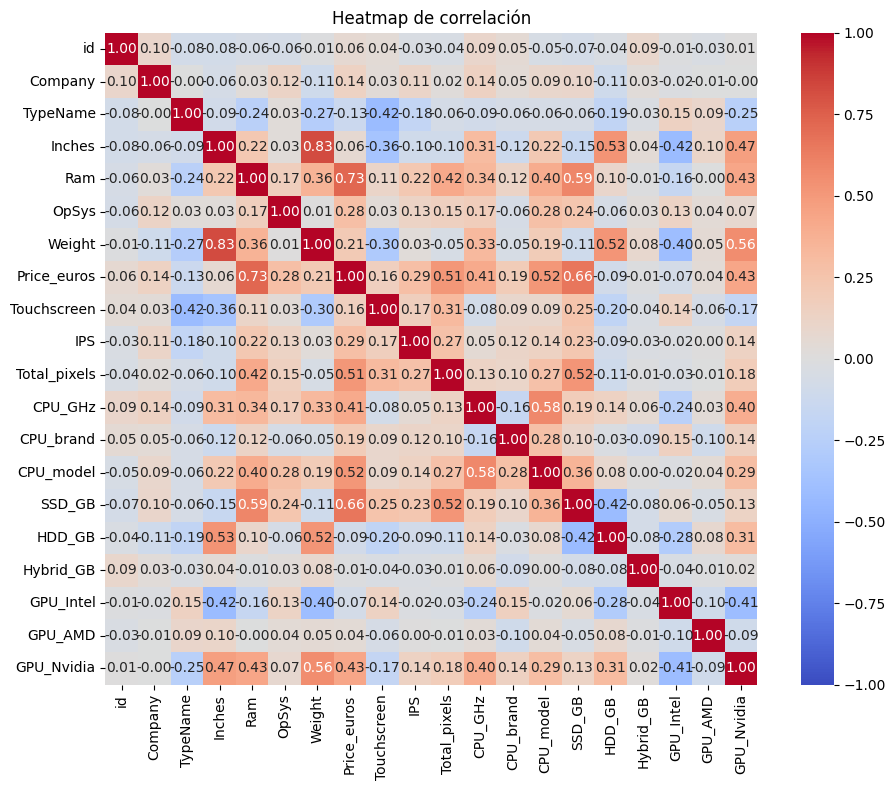

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_train.corr(),
    annot=True,        # muestra los valores
    fmt=".2f",         # 2 decimales
    cmap="coolwarm",   # paleta de colores
    vmin=-1, vmax=1,   # rango de correlación
    square=True
)
plt.title("Heatmap de correlación")
plt.tight_layout()
plt.show()

Con el heatmap vemos que Price_euros (target) tiene:
- Fuerte correlación lineal con Ram
- Correlación lineal media con SSD_GB, CPU_model y Total_pixels
- Algo de correlación lineal con GPU_Nvidia y CPU_GHZ

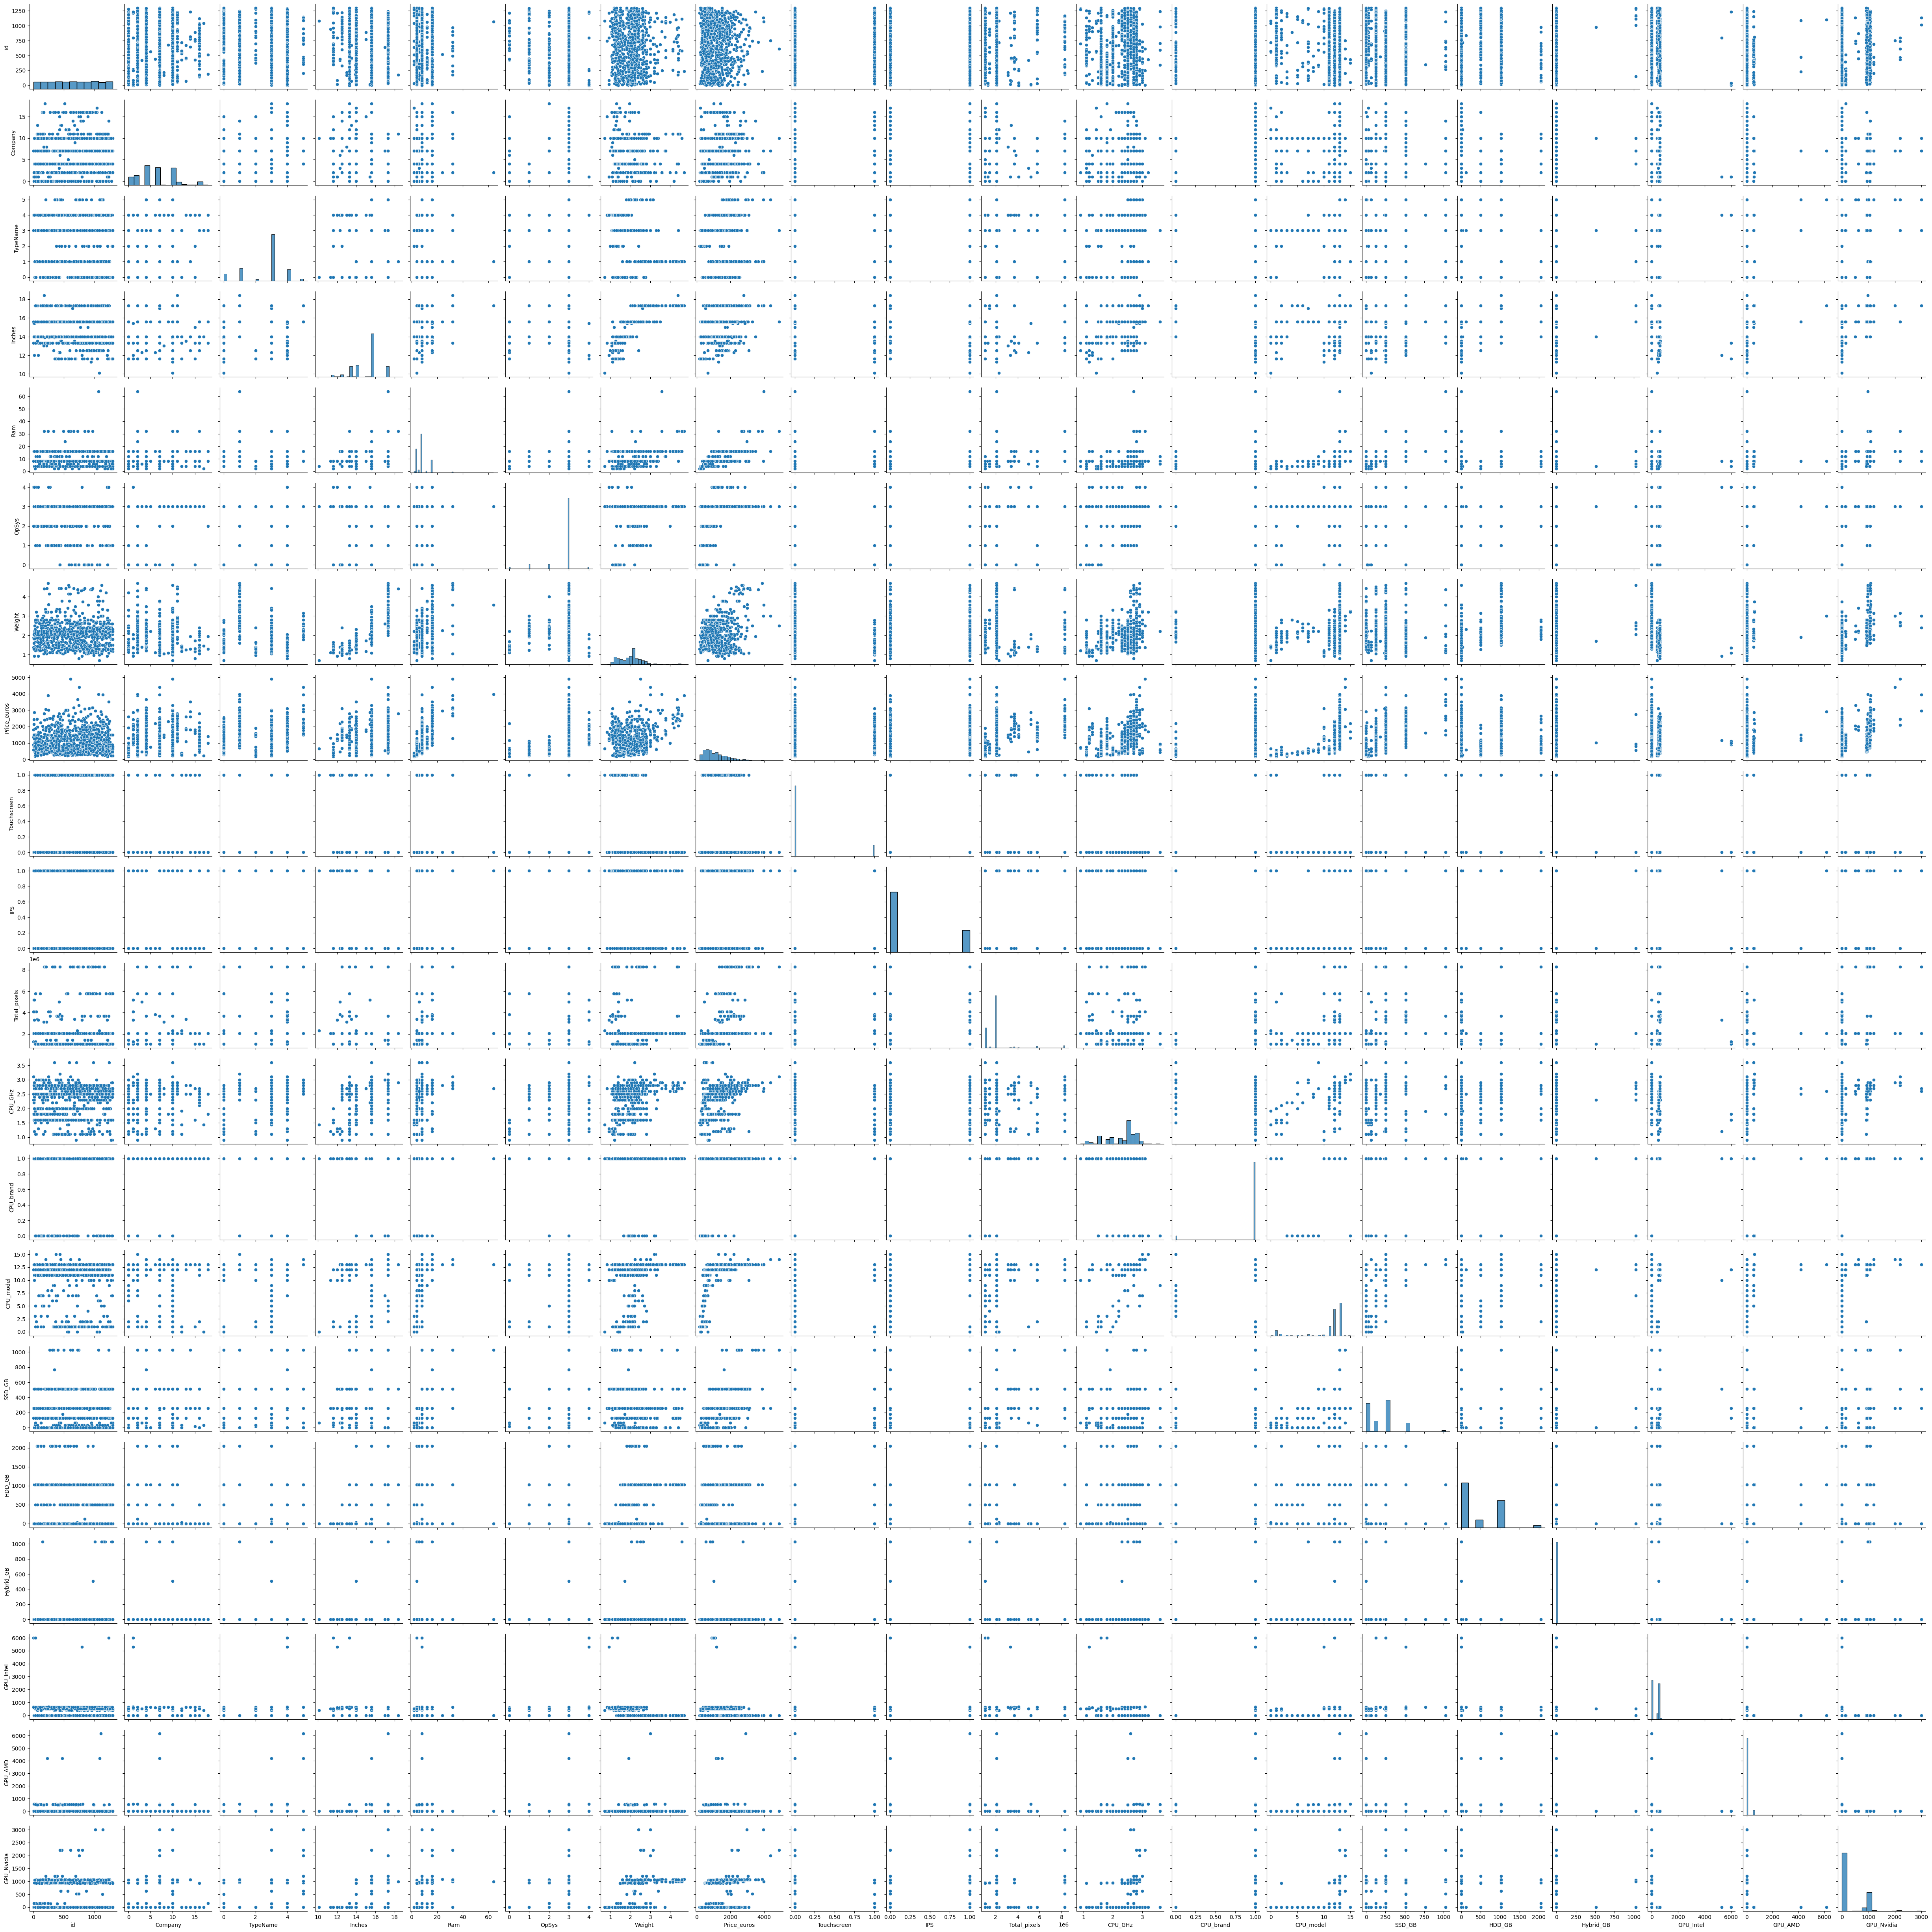

In [9]:
sns.pairplot(df_train);

Con el pairplot vemos que Price_euros (target) tiene:
1. RAM: relación ascendente (confirmado)
2. Relación algo exponencial con CPU_model  

No se aprecian relaciones polinómicas muy evidentes.

1. Regresión Lineal

Voy a seleccionar las variables RAM, CPU_model, Total_pixels y GPU_Nvidia.  
Algunas tienen algo de relación, pero no exagerada.  
No cojo SSD_GB porque tiene correlación con RAM.  
No cojo CPU_GHZ porque tiene correlación con CPU_model.

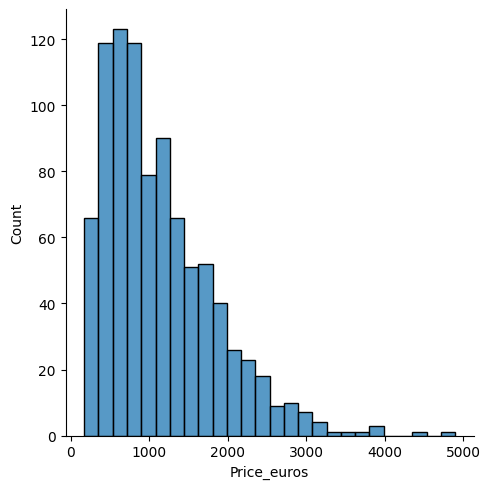

In [ ]:
sns.displot(df_train['Price_euros']); # No sigue una distribución normal, no es lo mejor para una regresión lineal

In [14]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_train[["Ram", "CPU_model", "Total_pixels", "GPU_Nvidia"]], df_train["Price_euros"], test_size = 0.2, random_state=42)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_pred_train = lr.predict(X_train)

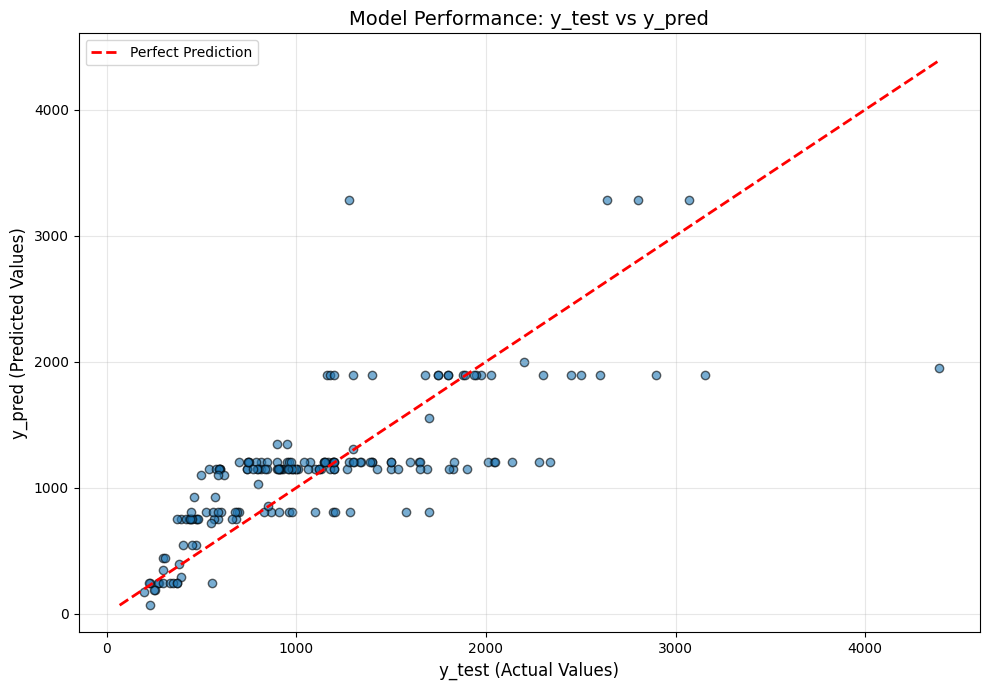

In [24]:
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')

# Perfect prediction line (diagonal)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('y_test (Actual Values)', fontsize=12)
plt.ylabel('y_pred (Predicted Values)', fontsize=12)
plt.title('Model Performance: y_test vs y_pred', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train r2_score:", r2_score(y_train, y_pred_train))
print("Test r2_score:", r2_score(y_test, y_pred))

Train MAE: 314.80740254869903
Test MAE: 306.8624731079274
Train MAPE: 0.3216850720098682
Test MAPE: 0.3038643074230069
Train MSE: 173484.91912852268
Test MSE: 181951.84136019336
Train RMSE: 416.5152087601636
Test RMSE: 426.55813362330036
Train r2_score: 0.6475540233608086
Test r2_score: 0.5961607392918513


R² de 0.60 en test → el modelo explica solo el 60% de la varianza en precios. Mejorable.  
MAE de ~307€ en test → de media, el modelo se equivoca en 307€. Bastante error para precios de PCs.  
MAPE de 30% → se equivoca un 30% del precio real de media. Si un PC vale 1000€, predice entre 700-1300€.  
Train vs Test muy parecidos → no hay overfitting, el modelo generaliza bien... pero generaliza mal.

2. Regresión polinómica

In [ ]:
X = df_train[["Ram", "CPU_model", "Total_pixels", "GPU_Nvidia"]]
y = df_train["Price_euros"]

# Para la linear:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, shuffle=True, random_state=42)

In [ ]:
# Ahora en polinómica grado 2: 
from sklearn.preprocessing import PolynomialFeatures

poly_feats = PolynomialFeatures(degree = 2)
poly_feats.fit(X)
X_poly = poly_feats.transform(X)
X_poly

array([[1.00000000e+00, 4.00000000e+00, 1.00000000e+01, ...,
        4.29981696e+12, 0.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 8.00000000e+00, 1.50000000e+01, ...,
        4.29981696e+12, 0.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 4.00000000e+00, 1.30000000e+01, ...,
        4.29981696e+12, 0.00000000e+00, 0.00000000e+00],
       ...,
       [1.00000000e+00, 8.00000000e+00, 1.20000000e+01, ...,
        4.29981696e+12, 2.17728000e+09, 1.10250000e+06],
       [1.00000000e+00, 4.00000000e+00, 5.00000000e+00, ...,
        1.10058563e+12, 0.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 8.00000000e+00, 1.30000000e+01, ...,
        4.29981696e+12, 2.19801600e+09, 1.12360000e+06]], shape=(910, 15))

In [27]:
poly_feats.get_feature_names_out()

array(['1', 'Ram', 'CPU_model', 'Total_pixels', 'GPU_Nvidia', 'Ram^2',
       'Ram CPU_model', 'Ram Total_pixels', 'Ram GPU_Nvidia',
       'CPU_model^2', 'CPU_model Total_pixels', 'CPU_model GPU_Nvidia',
       'Total_pixels^2', 'Total_pixels GPU_Nvidia', 'GPU_Nvidia^2'],
      dtype=object)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size = 0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_pred_train = lr.predict(X_train)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train r2_score:", r2_score(y_train, y_pred_train))
print("Test r2_score:", r2_score(y_test, y_pred))

Train MAE: 292.3410092330009
Test MAE: 280.8309909818429
Train MAPE: 0.2967132741522082
Test MAPE: 0.2834047313705555
Train MSE: 151539.81726547348
Test MSE: 145993.86250148527
Train RMSE: 389.28115452134784
Test RMSE: 382.09143212258147
Train r2_score: 0.6921369352209399
Test r2_score: 0.6759689099061488


R² subió de 0.60 → 0.68, explica más varianza.  
MAE bajó ~27€, predice mejor en media.  
Test MSE < Train MSE → inusual pero indica que no hay overfitting en absoluto.  

In [29]:
# Grado 3:
poly_feats = PolynomialFeatures(degree = 3)
poly_feats.fit(X)
X_poly = poly_feats.transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size = 0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_pred_train = lr.predict(X_train)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train r2_score:", r2_score(y_train, y_pred_train))
print("Test r2_score:", r2_score(y_test, y_pred))

Train MAE: 280.3396397555081
Test MAE: 264.83068558705685
Train MAPE: 0.27546809636803604
Test MAPE: 0.26272549591444994
Train MSE: 144237.92526071068
Test MSE: 136776.96119403312
Train RMSE: 379.7866838907213
Test RMSE: 369.83369396802277
Train r2_score: 0.7069712071095873
Test r2_score: 0.6964256779289195


In [30]:
# Grado 4:
poly_feats = PolynomialFeatures(degree = 4)
poly_feats.fit(X)
X_poly = poly_feats.transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size = 0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_pred_train = lr.predict(X_train)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train r2_score:", r2_score(y_train, y_pred_train))
print("Test r2_score:", r2_score(y_test, y_pred))

Train MAE: 301.409282217054
Test MAE: 281.84082182289416
Train MAPE: 0.3199011730522158
Test MAPE: 0.31197775578992554
Train MSE: 162189.00660077724
Test MSE: 145745.83487873917
Train RMSE: 402.7269628430374
Test RMSE: 381.7667283548151
Train r2_score: 0.6705024095540935
Test r2_score: 0.6765194033282336


Grado 3 → mejor en todas las métricas  
Grado 4 → empeora respecto al 3, señal de que empieza a overfit (Train R² baja pero el modelo se complica más)

3. Ridge y Lasso

In [46]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [47]:
X = df_train[["Ram", "CPU_model", "Total_pixels", "GPU_Nvidia"]]
y = df_train["Price_euros"]

# Para la linear:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, shuffle=True, random_state=42)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_pred_train = lr.predict(X_train)

baseline_error = mean_squared_error(y_test, y_pred)

In [48]:
# RIDGE

n_alphas = 100 # PROBAMOS 100 ALPHAS DISTINTOS
alphas = np.logspace(-2, 4, n_alphas) # por defecto es sobre base 10

coef_ridge = []
err_ridge = []
baseline = []

for a in alphas:
    ridge = Ridge(alpha=a) # probamos todas las alphas
    ridge.fit(X_train, y_train)
    
    coef_ridge.append(ridge.coef_)
    
    y_pred = ridge.predict(X_test)
    ridge_error = mean_squared_error(y_pred, y_test) # MSE de todos los predictores
    
    err_ridge.append(ridge_error)
    baseline.append(baseline_error)

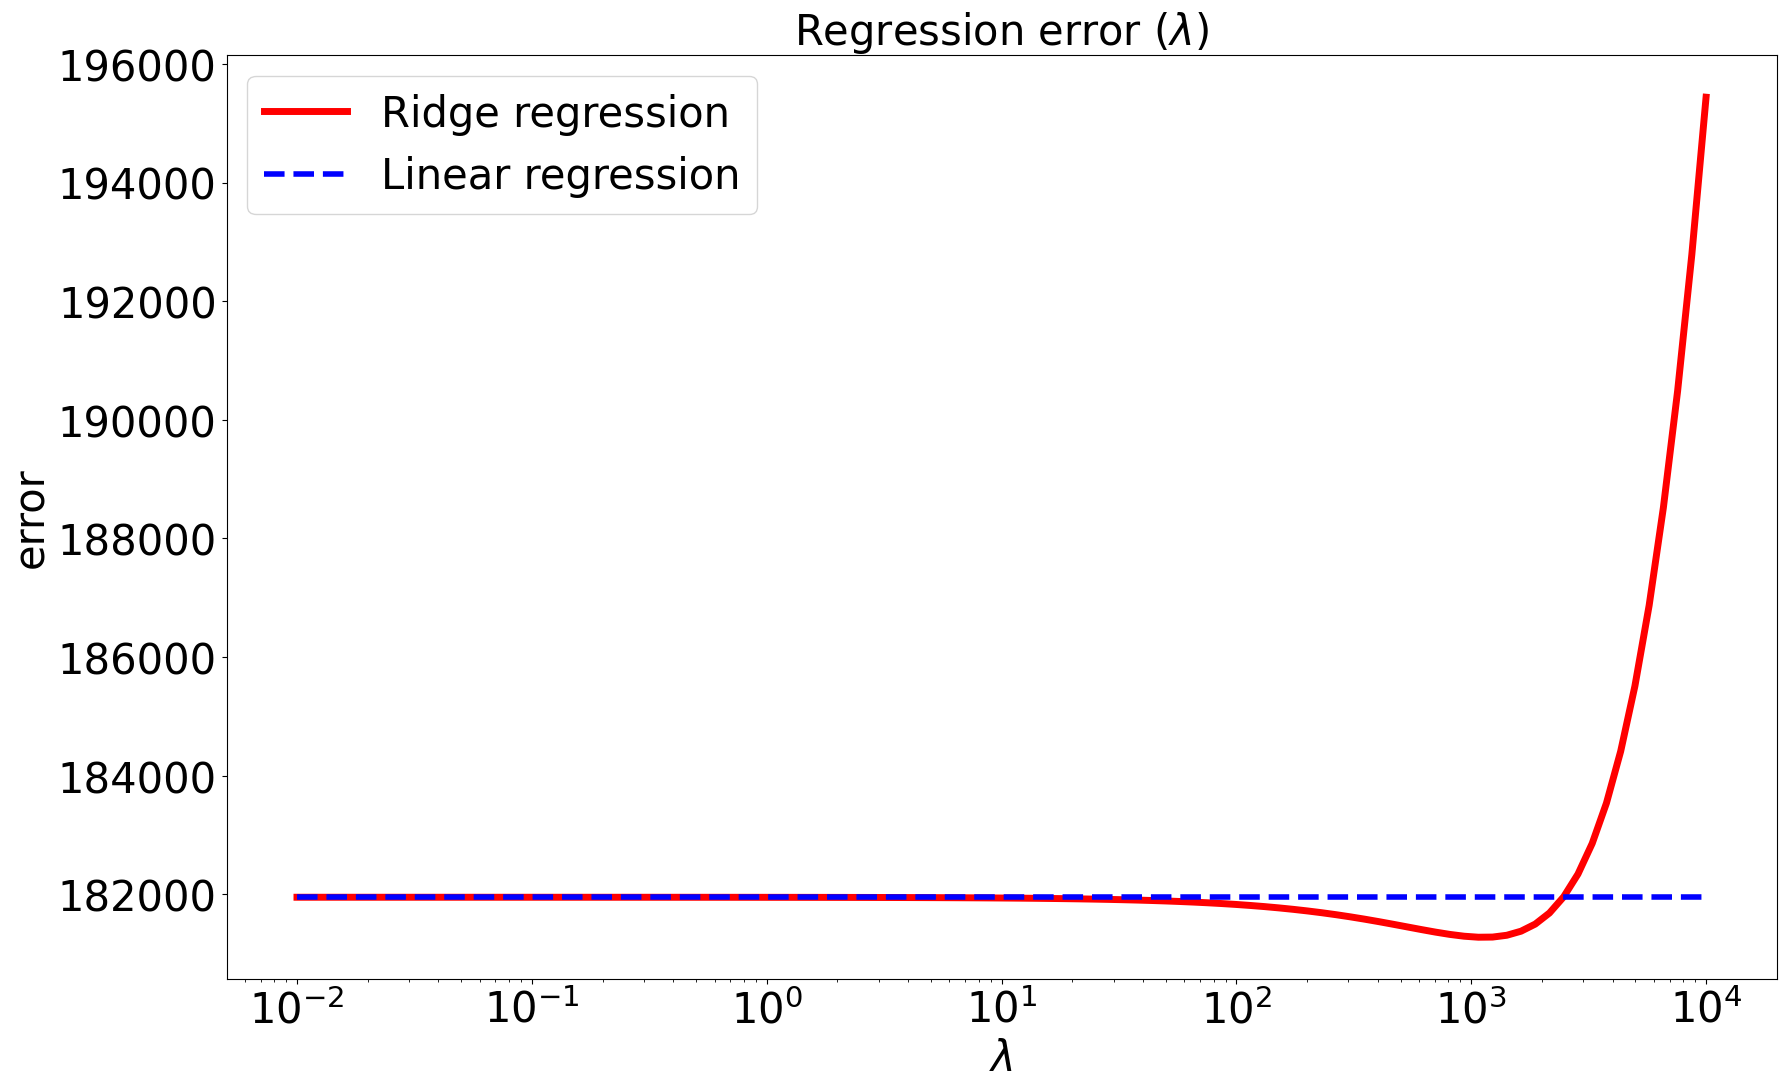

In [49]:
plt.figure(figsize=(20,12))
ax = plt.gca()
ax.plot(alphas, err_ridge, linewidth=5, color='red', label="Ridge regression")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.xlabel(r'$\lambda$', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('error', fontsize=30)
ax.legend(fontsize=30)
plt.title(r'Regression error ($\lambda$)', fontsize=30)
plt.show()

In [52]:
from sklearn.linear_model import RidgeCV

ridge_poly_cv = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('ridge', RidgeCV(alphas=np.logspace(-4, 3, 100)))
])

ridge_poly_cv.fit(X_train, y_train)
print("Mejor alpha:", ridge_poly_cv.named_steps['ridge'].alpha_)

Mejor alpha: 1000.0


In [53]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

ridge_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('ridge', Ridge(alpha=1000))
])

ridge_poly.fit(X_train, y_train)

y_pred_train = ridge_poly.predict(X_train)
y_pred = ridge_poly.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train r2_score:", r2_score(y_train, y_pred_train))
print("Test r2_score:", r2_score(y_test, y_pred))

Train MAE: 288.76323711602305
Test MAE: 277.9894215465742
Train MAPE: 0.2889159505093141
Test MAPE: 0.2786510213248688
Train MSE: 149899.63086705495
Test MSE: 144350.73975235684
Train RMSE: 387.1687369443134
Test RMSE: 379.93517835593593
Train r2_score: 0.6954690813231188
Test r2_score: 0.6796157951000568


c:\Users\cchia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.087535758664231e-27.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Mejora ligeramente pero no supera al polinómico grado 3 sin regularizar.

In [ ]:
# LASO sobre la lineal

from sklearn import linear_model

n_alphas = 100
alphas = np.logspace(-1, 6, n_alphas)

lasso = linear_model.Lasso(fit_intercept=False)

coef_lasso = []
err_lasso = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_train, y_train)
    coef_lasso.append(lasso.coef_)
    y_pred = lasso.predict(X_test)
    lasso_error = mean_squared_error(y_pred, y_test)    
    err_lasso.append(lasso_error)

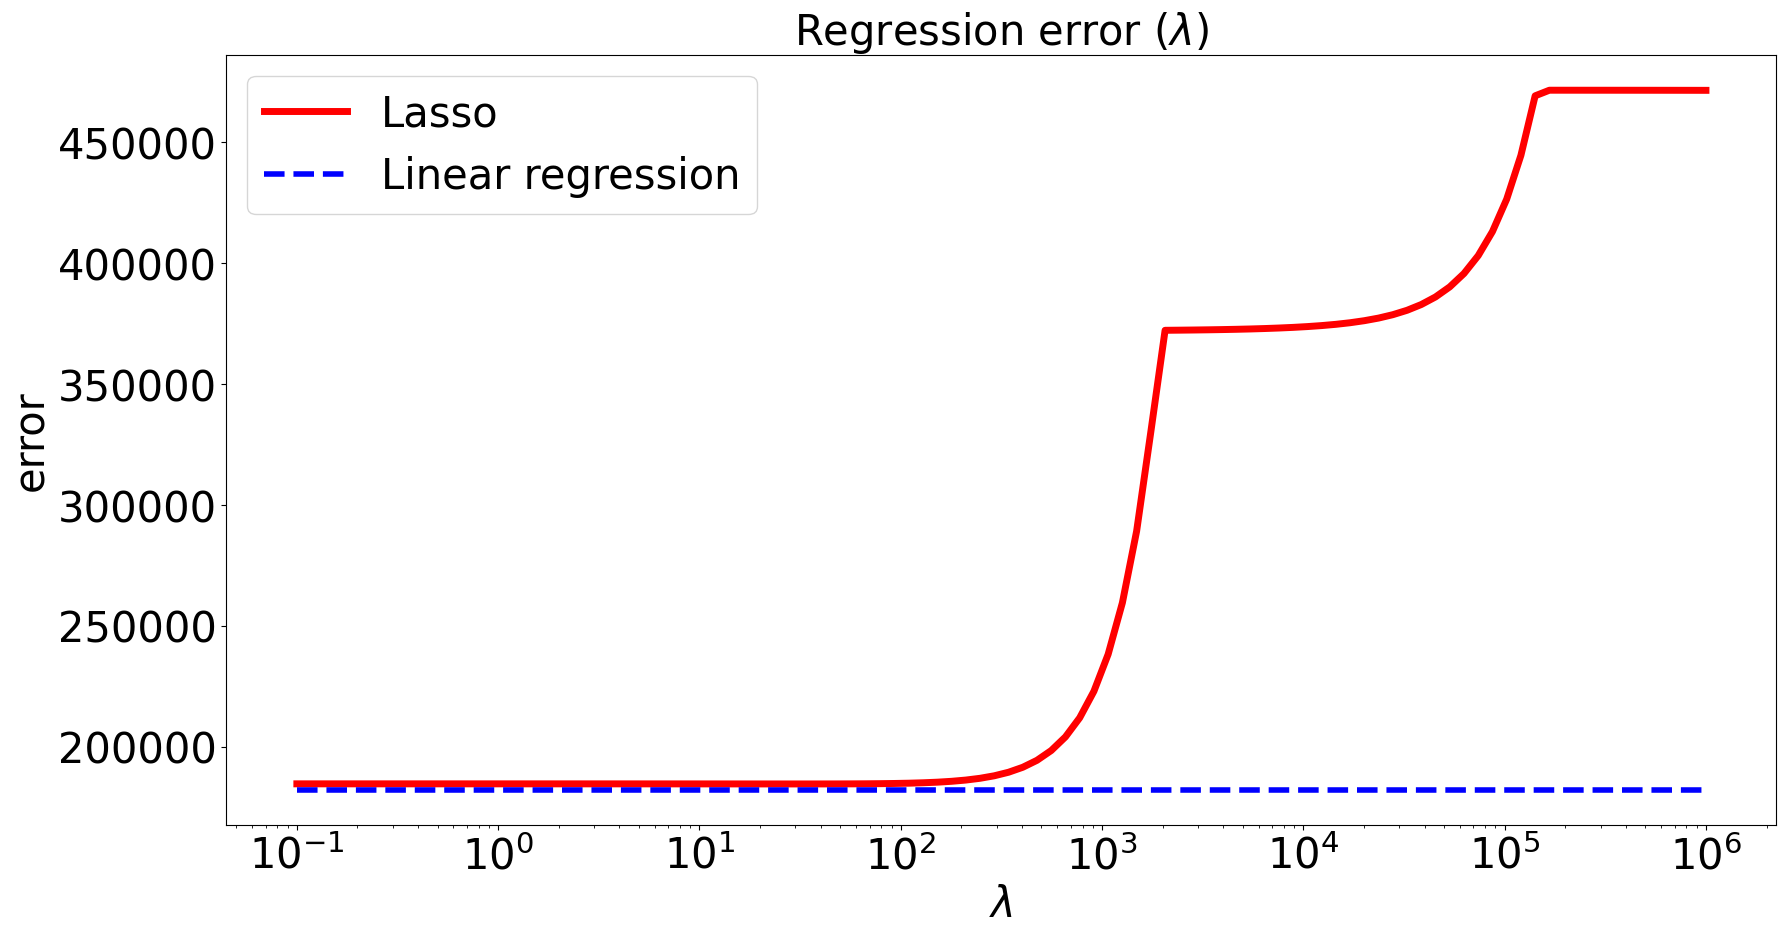

In [55]:
plt.figure(figsize=(20,10))
ax = plt.gca()
ax.plot(alphas, err_lasso, linewidth=5, color='red', label="Lasso")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.xlabel(r'$\lambda$', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('error', fontsize=30)
ax.legend(fontsize=30)
plt.title(r'Regression error ($\lambda$)', fontsize=30)
plt.show()

In [57]:
# Mejor alpha
best_alpha_lasso = alphas[np.argmin(err_lasso)]
print("Mejor alpha:", best_alpha_lasso)


Mejor alpha: 29.836472402833373


In [58]:
# Entrenar con mejor alpha y calcular métricas
lasso_best = linear_model.Lasso(alpha=best_alpha_lasso, fit_intercept=False)
lasso_best.fit(X_train, y_train)

y_pred_train = lasso_best.predict(X_train)
y_pred = lasso_best.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train r2_score:", r2_score(y_train, y_pred_train))
print("Test r2_score:", r2_score(y_test, y_pred))

Train MAE: 323.0510948112283
Test MAE: 319.6083439650086
Train MAPE: 0.3393802385507301
Test MAPE: 0.3437896214955166
Train MSE: 177827.62184727655
Test MSE: 184547.25815419186
Train RMSE: 421.6961250086092
Test RMSE: 429.58963925377884
Train r2_score: 0.6387315383364418
Test r2_score: 0.5904002523878304


In [64]:
# LASO sobre la polinómica de 3 grado (con escalado incluido)

from sklearn.preprocessing import StandardScaler

# Escalar FUERA del pipeline
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_alphas = 100
alphas = np.logspace(-1, 6, n_alphas)

err_lasso = []
baseline_error = mean_squared_error(y_test, lr.predict(X_test))
baseline = []

for a in alphas:
    lasso = linear_model.Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)
    err_lasso.append(mean_squared_error(y_pred, y_test))
    baseline.append(baseline_error)

best_alpha_lasso = alphas[np.argmin(err_lasso)]
print("Mejor alpha:", best_alpha_lasso)

# Métricas con mejor alpha
lasso_best = linear_model.Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_best.fit(X_train_scaled, y_train)

y_pred_train = lasso_best.predict(X_train_scaled)
y_pred = lasso_best.predict(X_test_scaled)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train r2_score:", r2_score(y_train, y_pred_train))
print("Test r2_score:", r2_score(y_test, y_pred))

Mejor alpha: 21.54434690031882
Train MAE: 313.1965791671144
Test MAE: 307.32131992868955
Train MAPE: 0.3151782594365486
Test MAPE: 0.3085922671362008
Train MSE: 174440.4388244104
Test MSE: 181004.73667201836
Train RMSE: 417.660674261308
Test RMSE: 425.44651446688147
Train r2_score: 0.6456128225111506
Test r2_score: 0.5982628233060969


No mejora, la polinómica de grado 3 sigue siendo la mejor.

4. Ensembles

In [65]:
X = df_train.drop("Price_euros", axis=1)
y = df_train["Price_euros"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, shuffle=True, random_state=42)

In [69]:
# Bagging

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

estimator = DecisionTreeRegressor(max_depth=3, random_state=42)

bag_clf = BaggingRegressor(
    estimator=estimator,
    n_estimators=100,
    bootstrap=True,
    max_features=3,
    random_state=42)

bag_clf.fit(X_train, y_train)

y_pred_train = bag_clf.predict(X_train)
y_pred = bag_clf.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred))

Train MAE: 319.9300062358723
Test MAE: 308.60378101844907
Train MAPE: 0.3901975148797878
Test MAPE: 0.4093403354464281
Train MSE: 174333.36387040766
Test MSE: 163805.73607391797
Train RMSE: 417.53247043841714
Test RMSE: 404.7292132697095
Train R²: 0.6458303522937201
Test R²: 0.6364357356247266


In [74]:
from sklearn.model_selection import GridSearchCV

# Bagging
param_grid_bag = {
    'n_estimators': [50, 100, 200],
    'max_features': [2, 3, 5],
    'estimator__max_depth': [3, 5, 10]
}
grid_bag = GridSearchCV(BaggingRegressor(estimator=DecisionTreeRegressor(), random_state=42),
                        param_grid_bag, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_bag.fit(X_train, y_train)
print("Bagging - Mejor params:", grid_bag.best_params_)

Bagging - Mejor params: {'estimator__max_depth': 10, 'max_features': 5, 'n_estimators': 50}


In [75]:
estimator = DecisionTreeRegressor(max_depth=10, random_state=42)

bag_clf = BaggingRegressor(
    estimator=estimator,
    n_estimators=50,
    bootstrap=True,
    max_features=5,
    random_state=42)

bag_clf.fit(X_train, y_train)

y_pred_train = bag_clf.predict(X_train)
y_pred = bag_clf.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred))

Train MAE: 150.28922800069762
Test MAE: 205.61585027036728
Train MAPE: 0.1554306584798527
Test MAPE: 0.23223580642670516
Train MSE: 42414.702403773634
Test MSE: 85254.34140813314
Train RMSE: 205.94830031775848
Test RMSE: 291.9834608468999
Train R²: 0.9138317538628007
Test R²: 0.8107793251827302


¡Mejora una barbaridad!

In [70]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred = rf.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred))

Train MAE: 65.67230810439561
Test MAE: 184.92666593406594
Train MAPE: 0.058670177566918405
Test MAPE: 0.18216392308854035
Train MSE: 10663.974630065506
Test MSE: 78572.97564380067
Train RMSE: 103.2665223103088
Test RMSE: 280.30871489092283
Train R²: 0.9783354370383941
Test R²: 0.8256085117994647


In [76]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'max_features': ['sqrt', 'log2', None]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42),
                       param_grid_rf, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print("Random Forest - Mejor params:", grid_rf.best_params_)

Random Forest - Mejor params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}


In [78]:
rf = RandomForestRegressor(n_estimators=50, max_depth=None, max_features="sqrt", random_state=42)
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred = rf.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred))

Train MAE: 65.21960384615384
Test MAE: 168.80063296703295
Train MAPE: 0.05853449352476823
Test MAPE: 0.16805814165025149
Train MSE: 10408.01421538649
Test MSE: 69287.84795969585
Train RMSE: 102.0196756287065
Test RMSE: 263.2258497178722
Train R²: 0.9788554373864686
Test R²: 0.8462167071961066


De momento, el MEJOR :)

In [71]:
# AdaBoost

from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

y_pred_train = ada.predict(X_train)
y_pred = ada.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred))

Train MAE: 325.338832141303
Test MAE: 346.45308982151096
Train MAPE: 0.48071457928269357
Test MAPE: 0.5102964300483099
Train MSE: 136984.28610613948
Test MSE: 168268.36913188614
Train RMSE: 370.11388261741746
Test RMSE: 410.2052768211132
Train R²: 0.7217074501724623
Test R²: 0.6265309914821597


In [79]:
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'estimator__max_depth': [1, 3, 5]
}
grid_ada = GridSearchCV(AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=42),
                        param_grid_ada, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_ada.fit(X_train, y_train)
print("AdaBoost - Mejor params:", grid_ada.best_params_)

AdaBoost - Mejor params: {'estimator__max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 200}


In [82]:
ada = AdaBoostRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
ada.fit(X_train, y_train)

y_pred_train = ada.predict(X_train)
y_pred = ada.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred))

Train MAE: 278.66281573993336
Test MAE: 298.5007975757232
Train MAPE: 0.35690200164116553
Test MAPE: 0.37799353897717514
Train MSE: 111505.94035772848
Test MSE: 141757.87349512894
Train RMSE: 333.92505200677664
Test RMSE: 376.5074680469551
Train R²: 0.7734683784165897
Test R²: 0.6853706211276822


Malo :(

In [72]:
# Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

y_pred_train = gb.predict(X_train)
y_pred = gb.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred))

Train MAE: 123.98420479105438
Test MAE: 185.12422552014797
Train MAPE: 0.1283462859638451
Test MAPE: 0.18738864265534944
Train MSE: 29619.665337724487
Test MSE: 78349.81256352487
Train RMSE: 172.10364707851048
Test RMSE: 279.9103652305946
Train R²: 0.9398257097497532
Test R²: 0.8261038187591646


In [83]:
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=42),
                       param_grid_gb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_gb.fit(X_train, y_train)
print("Gradient Boosting - Mejor params:", grid_gb.best_params_)

Gradient Boosting - Mejor params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}


In [85]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.2, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

y_pred_train = gb.predict(X_train)
y_pred = gb.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred))

Train MAE: 94.2266255637392
Test MAE: 174.55133653391735
Train MAPE: 0.09797284548095107
Test MAPE: 0.1773601641249449
Train MSE: 17206.688873091578
Test MSE: 76110.35508423182
Train RMSE: 131.17426909684528
Test RMSE: 275.8810524197554
Train R²: 0.9650434844995907
Test R²: 0.8310742595420899


Bastante bueno! :)

In [73]:
# XGBoost

from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

y_pred_train = xgb.predict(X_train)
y_pred = xgb.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred))

Train MAE: 10.985887644841121
Test MAE: 182.25549825144336
Train MAPE: 0.012481803273308188
Test MAPE: 0.17117958240943812
Train MSE: 367.9727896113893
Test MSE: 76188.99625288349
Train RMSE: 19.18261686036056
Test RMSE: 276.0235429322714
Train R²: 0.9992524391753317
Test R²: 0.8308997167005769


In [86]:
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
grid_xgb = GridSearchCV(XGBRegressor(random_state=42),
                        param_grid_xgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
print("XGBoost - Mejor params:", grid_xgb.best_params_)

XGBoost - Mejor params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}


In [89]:
xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=3, random_state=42)
xgb.fit(X_train, y_train)

y_pred_train = xgb.predict(X_train)
y_pred = xgb.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred))

Train MAE: 71.58971417689061
Test MAE: 170.88507652534233
Train MAPE: 0.07625326210473647
Test MAPE: 0.17062304313539445
Train MSE: 10260.41284181044
Test MSE: 75325.42588275595
Train RMSE: 101.29369596283097
Test RMSE: 274.4547793039064
Train R²: 0.9791552992449207
Test R²: 0.8328163976049014


Muy bueno :)

# RESULTADOS FINALES:

In [95]:
from sklearn.metrics import mean_absolute_error

X = df_train.drop(["Price_euros", "id"], axis=1)
y = df_train["Price_euros"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=42)

modelos = {
    "Bagging (grid)":        BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=10), n_estimators=50, max_features=5, random_state=42),
    "Random Forest (grid)":  RandomForestRegressor(n_estimators=50, max_depth=None, max_features="sqrt", random_state=42),
    "AdaBoost (grid)":       AdaBoostRegressor(estimator=DecisionTreeRegressor(), n_estimators=200, learning_rate=0.1, random_state=42),
    "Gradient Boosting (grid)": GradientBoostingRegressor(n_estimators=100, learning_rate=0.2, max_depth=3, random_state=42),
    "XGBoost (grid)":        XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=3, random_state=42),
}

for name, model in modelos.items():
    model.fit(X_train, y_train)
    print(f"{name} → Test MAE: {mean_absolute_error(y_test, model.predict(X_test)):.2f}€")

Bagging (grid) → Test MAE: 203.79€
Random Forest (grid) → Test MAE: 174.06€
AdaBoost (grid) → Test MAE: 185.70€
Gradient Boosting (grid) → Test MAE: 171.52€
XGBoost (grid) → Test MAE: 167.89€


In [96]:
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

X_ens = df_train.drop(["Price_euros", "id"], axis=1)
X_lin = df_train[["Ram", "CPU_model", "Total_pixels", "GPU_Nvidia"]]
y = df_train["Price_euros"]

X_train_ens, X_test_ens, y_train, y_test = train_test_split(X_ens, y, test_size=0.20, shuffle=True, random_state=42)
X_train_lin, X_test_lin, _, _ = train_test_split(X_lin, y, test_size=0.20, shuffle=True, random_state=42)

resultados = {}

# Lineal
lr = LinearRegression()
lr.fit(X_train_lin, y_train)
resultados["Lineal"] = mean_absolute_error(y_test, lr.predict(X_test_lin))

# Polinómica grado 2
poly2 = PolynomialFeatures(degree=2)
X_train_p2 = poly2.fit_transform(X_train_lin)
X_test_p2 = poly2.transform(X_test_lin)
lr2 = LinearRegression()
lr2.fit(X_train_p2, y_train)
resultados["Poly grado 2"] = mean_absolute_error(y_test, lr2.predict(X_test_p2))

# Polinómica grado 3 (mejor)
poly3 = PolynomialFeatures(degree=3)
X_train_p3 = poly3.fit_transform(X_train_lin)
X_test_p3 = poly3.transform(X_test_lin)
lr3 = LinearRegression()
lr3.fit(X_train_p3, y_train)
resultados["Poly grado 3"] = mean_absolute_error(y_test, lr3.predict(X_test_p3))

# Ridge Poly grado 2
from sklearn.pipeline import Pipeline
ridge_poly = Pipeline([('poly', PolynomialFeatures(degree=2)), ('ridge', Ridge(alpha=1000))])
ridge_poly.fit(X_train_lin, y_train)
resultados["Ridge Poly 2"] = mean_absolute_error(y_test, ridge_poly.predict(X_test_lin))

# Ensembles
modelos_ens = {
    "Bagging (grid)":             BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=10), n_estimators=50, max_features=5, random_state=42),
    "Random Forest (grid)":       RandomForestRegressor(n_estimators=50, max_depth=None, max_features="sqrt", random_state=42),
    "AdaBoost (grid)":            AdaBoostRegressor(estimator=DecisionTreeRegressor(), n_estimators=200, learning_rate=0.1, random_state=42),
    "Gradient Boosting (grid)":   GradientBoostingRegressor(n_estimators=100, learning_rate=0.2, max_depth=3, random_state=42),
    "XGBoost (grid)":             XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=3, random_state=42),
}

for name, model in modelos_ens.items():
    model.fit(X_train_ens, y_train)
    resultados[name] = mean_absolute_error(y_test, model.predict(X_test_ens))

# Ranking por MAE
print("=== RANKING POR TEST MAE ===")
for name, mae in sorted(resultados.items(), key=lambda x: x[1]):
    print(f"{name:30s} → {mae:.2f}€")

c:\Users\cchia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.087535758664231e-27.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


=== RANKING POR TEST MAE ===
XGBoost (grid)                 → 167.89€
Gradient Boosting (grid)       → 171.52€
Random Forest (grid)           → 174.06€
AdaBoost (grid)                → 185.70€
Bagging (grid)                 → 203.79€
Poly grado 3                   → 264.83€
Ridge Poly 2                   → 277.99€
Poly grado 2                   → 280.83€
Lineal                         → 306.86€


In [104]:
X = df_train.drop(["Price_euros", "id"], axis=1) # tengo que dropear id para entrenar los modelos
y = df_train["Price_euros"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=42)

In [105]:
# Random Forest
rf_final = RandomForestRegressor(n_estimators=50, max_depth=None, max_features="sqrt", random_state=42)
rf_final.fit(X_train, y_train)
pd.DataFrame({'id': df_test['id'], 'Price_euros': rf_final.predict(df_test.drop('id', axis=1))}).to_csv("submission_rf.csv", index=False)

In [106]:
# Gradient Boosting
gb_final = GradientBoostingRegressor(n_estimators=100, learning_rate=0.2, max_depth=3, random_state=42)
gb_final.fit(X_train, y_train)
pd.DataFrame({'id': df_test['id'], 'Price_euros': gb_final.predict(df_test.drop('id', axis=1))}).to_csv("submission_gb.csv", index=False)

In [107]:
# XGBoost
xgb_final = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=3, random_state=42)
xgb_final.fit(X_train, y_train)
pd.DataFrame({'id': df_test['id'], 'Price_euros': xgb_final.predict(df_test.drop('id', axis=1))}).to_csv("submission_xgb.csv", index=False)